In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import qnmfits
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter 

plt.style.use("~/PhD/subdom_asym/code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

### CCE $q=1$ superkick waveform with $(2,\pm2)$ and $(3,\pm2)$ QNM fits

In [23]:
abd = qnmfits.cce.load(9)
abd_prime = qnmfits.utils.to_superrest_frame(abd, t0=300)
Mf_prime = abd_prime.bondi_rest_mass()[-1]
chif_prime = np.linalg.norm(abd_prime.bondi_dimensionless_spin()[-1])
h_prime = abd_prime.h
data = h_prime.data.T 
mode_list = [(ell,m) for ell in range(h_prime.ell_min, h_prime.ell_max + 1) for m in range(-ell,ell+1)]
h_prime_dict = dict(zip(mode_list, data))

In [24]:
ell = 2
mm = 2
qnms = [(l,m,n,p) for p in [-1,1] for m in [mm, -mm] for l in [3,2] for n in range(0,7)]
spherical_modes = [(ell,mm),(ell,-mm)]
t0 = 30

best_fit_22 = qnmfits.fit(
    data=h_prime,
    chif=np.linalg.norm(chif_prime), 
    Mf=Mf_prime,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0
)

In [25]:
ell = 3
mm = 2
qnms = [(l,m,n,p) for p in [-1,1] for m in [mm, -mm] for l in [3,2] for n in range(0,7)]
spherical_modes = [(ell,mm),(ell,-mm)]
t0 = 30

best_fit_32 = qnmfits.fit(
    data=h_prime,
    chif=np.linalg.norm(chif_prime), 
    Mf=Mf_prime,
    qnms=qnms,
    spherical_modes=spherical_modes,
    t0=t0
)

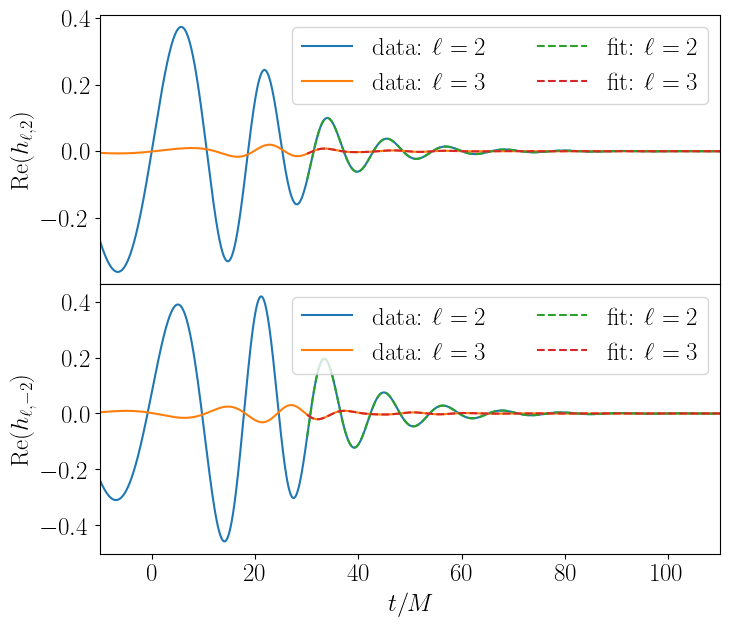

In [26]:
# extract waveforms from best fit models
h_fit_32 = best_fit_32['model']
h32_fit  = h_fit_32.data[:, h_fit_32.index(3, 2)]
h3m2_fit = h_fit_32.data[:, h_fit_32.index(3, -2)]

h_fit_22 = best_fit_22['model']
h22_fit  = h_fit_22.data[:, h_fit_22.index(2, 2)]
h2m2_fit = h_fit_22.data[:, h_fit_22.index(2, -2)]

# Plot setup
fig, axs = plt.subplots(2, figsize=(8,7), sharex=True)
fig.subplots_adjust(hspace=0)

# Plot: +m
axs[0].plot(h_prime.t, np.real(h_prime_dict[(2,2)]), label=r'data: $\ell=2$')
axs[0].plot(h_prime.t, np.real(h_prime_dict[(3,2)]), label=r'data: $\ell=3$')
axs[0].plot(h_fit_22.t, np.real(h22_fit), ls='--', label=r'fit: $\ell=2$')
axs[0].plot(h_fit_32.t, np.real(h32_fit), ls='--', label=r'fit: $\ell=3$')

# Plot: -m
axs[1].plot(h_prime.t, np.real(h_prime_dict[(2,-2)]), label=r'data: $\ell=2$')
axs[1].plot(h_prime.t, np.real(h_prime_dict[(3,-2)]), label=r'data: $\ell=3$')
axs[1].plot(h_fit_22.t, np.real(h2m2_fit), ls='--', label=r'fit: $\ell=2$')
axs[1].plot(h_fit_32.t, np.real(h3m2_fit), ls='--', label=r'fit: $\ell=3$')

axs[1].set_xlabel(r'$t/M$')
axs[0].set_ylabel(r'Re$(h_{\ell,2})$')
axs[1].set_ylabel(r'Re$(h_{\ell,-2})$')

axs[0].legend(loc='upper right', ncol=2)
axs[1].legend(loc='upper right', ncol=2)
axs[0].set_xlim(-10, 110)

plt.show()


### $+/-$ ringdown waveform  

In [27]:
def h_minus(h, l, m):
    '''
    Returns the anti-symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    return (h[(l,m)] - (-1)**l * np.conjugate(h[(l,-m)]))/2


#-----------------------------------------------------------------------------------------------------


def a_minus(h, l, m):
    '''
    Returns the amplitude of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = np.abs(h_minus(h, l, m))
    return a 


#-----------------------------------------------------------------------------------------------------


def a_minus_dot(h, t, l, m):
    '''
    Returns the amplitude np.gradientative of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = a_minus(h, l, m)
    return np.gradient(a, t)


#-----------------------------------------------------------------------------------------------------


def phi_minus(h, l, m):
    '''
    Returns the phase of the anti-symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = np.unwrap(np.angle(h_minus(h, l, m)))
    return phi 


#-----------------------------------------------------------------------------------------------------


def phi_minus_dot(h, t, l, m):
    '''
    Returns the phase np.gradientative of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = phi_minus(h, l, m)
    return np.gradient(phi, t)


#-----------------------------------------------------------------------------------------------------

    
def h_plus(h, l, m):
    '''
    Returns the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    return (h[(l,m)] + (-1)**l * np.conjugate(h[(l,-m)]))/2    


#-----------------------------------------------------------------------------------------------------


def a_plus(h, l, m):
    '''
    Returns the amplitude of the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = np.abs(h_plus(h, l, m)) 
    return a


#-----------------------------------------------------------------------------------------------------


def a_plus_dot(h, t, l, m):
    '''
    Returns the amplitude np.gradientative of the symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = a_plus(h, l, m)
    return np.gradient(a, t)


#-----------------------------------------------------------------------------------------------------


def phi_plus(h, l, m):
    '''
    Returns the phase of the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = np.unwrap(np.angle(h_plus(h, l, m))) 
    return phi 


#-----------------------------------------------------------------------------------------------------


def phi_plus_dot(h, t, l, m):
    '''
    Returns the phase np.gradientative of the symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = phi_plus(h, l, m)
    return np.gradient(phi, t) 


#-----------------------------------------------------------------------------------------------------


def filter(x):

    return savgol_filter(x, int(len(x)/20), 3)


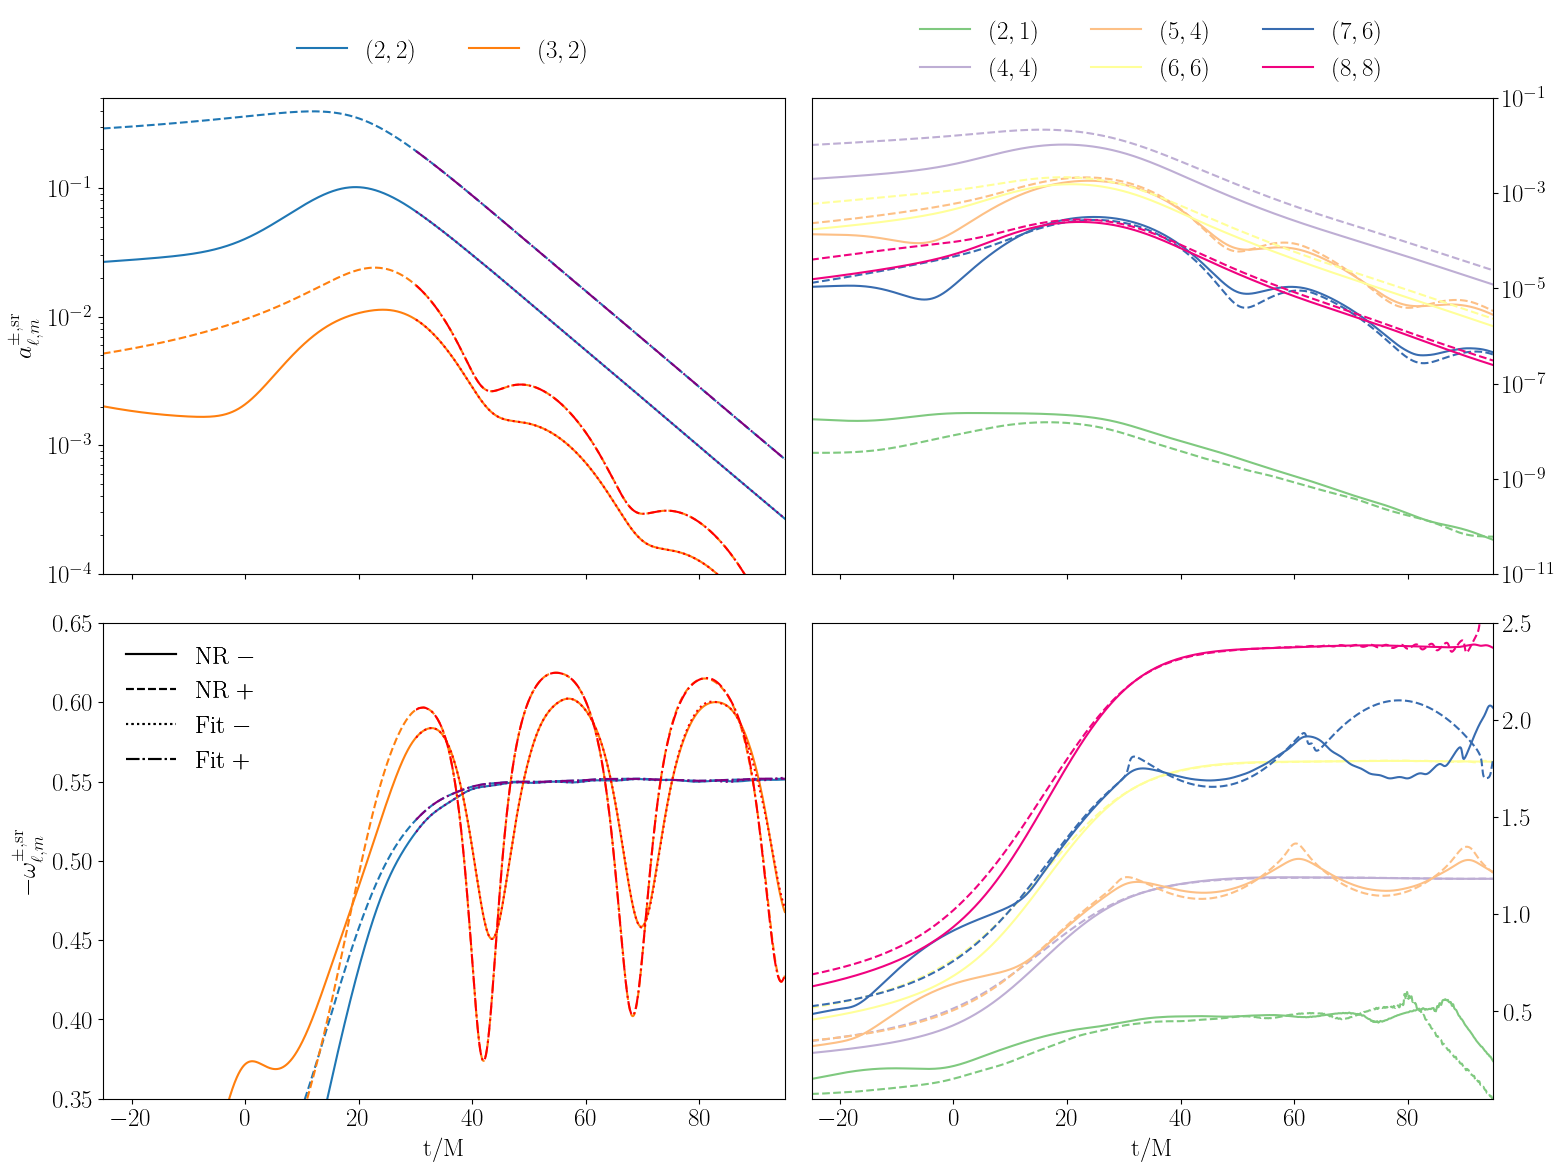

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(16,12))


lower_mode_list = [(2,2), (3,2), ]
higher_mode_list = [(2,1), (4,4), (5,4), (6,6), (7,6), (8,8)]
lower_mode_colors = plt.cm.tab10.colors
higher_mode_colors = plt.cm.Accent.colors

# --- Plot 1 ---
ax1 = axes[0,0]

for i, (ell, m) in enumerate(lower_mode_list):
    color = lower_mode_colors[i % len(lower_mode_colors)]
    ax1.semilogy(h_prime.t, a_minus(h_prime_dict, ell, m),
                 label=rf'${ell,m}$', color=color)
    ax1.semilogy(h_prime.t, a_plus(h_prime_dict, ell, m),
                 color=color, ls='--')
    
h_minus_22_fit = 0.5*(h22_fit - np.conjugate(h2m2_fit))
h_plus_22_fit = 0.5*(h22_fit + np.conjugate(h2m2_fit))
h_minus_32_fit = 0.5*(h32_fit + np.conjugate(h3m2_fit))
h_plus_32_fit = 0.5*(h32_fit - np.conjugate(h3m2_fit))


ax1.semilogy(h_fit_22.t, np.abs(h_minus_22_fit),
                color='purple', ls=':')
ax1.semilogy(h_fit_22.t, np.abs(h_plus_22_fit),
                color='purple', ls='-.')
ax1.semilogy(h_fit_32.t, np.abs(h_minus_32_fit),
                color='red', ls=':')
ax1.semilogy(h_fit_32.t, np.abs(h_plus_32_fit),
                color='red', ls='-.')
    

ax1.set_xlim(-25, 95)
ax1.set_ylim(1e-4, .5)
ax1.set_ylabel(r'$a^{\pm, \text{sr}}_{\ell,m}$')
ax1.legend(loc="center", bbox_to_anchor=(0.5, 1.1), frameon=False, ncol=2)




# --- Plot 2 ---
ax2 = axes[0,1]

for i, (ell, m) in enumerate(higher_mode_list):
    color = higher_mode_colors[i % len(higher_mode_colors)]
    ax2.semilogy(h_prime.t, filter(a_minus(h_prime_dict, ell, m)),
                 label=rf'${ell,m}$', color=color)
    ax2.semilogy(h_prime.t, filter(a_plus(h_prime_dict, ell, m)),
                 color=color, ls='--')

ax2.set_ylim(1e-11, 1e-1)
ax2.set_xlim(-25, 95)
ax2.legend(loc="center", bbox_to_anchor=(0.5, 1.1), frameon=False, ncol=3)
ax2.yaxis.tick_right()


# --- Plot 3 ---
ax3 = axes[1,0]

for i, (ell, m) in enumerate(lower_mode_list):
    color = lower_mode_colors[i % len(lower_mode_colors)]
    ax3.plot(h_prime.t, -phi_minus_dot(h_prime_dict, h_prime.t, ell, m), color=color)
    ax3.plot(h_prime.t, -phi_plus_dot(h_prime_dict, h_prime.t, ell, m), color=color, ls='--')

phi_minus_dot_22_fit =np.gradient(np.unwrap(np.angle(h_minus_22_fit)), h_fit_22.t)
phi_plus_dot_22_fit =np.gradient(np.unwrap(np.angle(h_plus_22_fit)), h_fit_22.t)
phi_minus_dot_32_fit =np.gradient(np.unwrap(np.angle(h_minus_32_fit)), h_fit_32.t)
phi_plus_dot_32_fit =np.gradient(np.unwrap(np.angle(h_plus_32_fit)), h_fit_32.t)

ax3.plot(h_fit_22.t, -phi_minus_dot_22_fit, color='purple', ls=':')
ax3.plot(h_fit_22.t, -phi_plus_dot_22_fit, color='purple', ls='-.')
ax3.plot(h_fit_32.t, -phi_minus_dot_32_fit, color='red', ls=':')
ax3.plot(h_fit_32.t, -phi_plus_dot_32_fit, color='red', ls='-.')

ax3.set_xlim(-25, 95)
ax3.set_ylim(.35, .65)
ax3.set_ylabel(r'$-\omega^{\pm,\text{sr}}_{\ell,m}$')
ax3.set_xlabel('t/M')

ax3.add_artist(ax3.legend(handles=[
    Line2D([0], [0], color='black', linestyle='-', label=r'NR $-$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'NR $+$'),
    Line2D([0], [0], color='black', linestyle=':', label=r'Fit $-$'),
    Line2D([0], [0], color='black', linestyle='-.', label=r'Fit $+$'),],
    loc="upper left", frameon=False))


# --- Plot 4 ---
ax4 = axes[1,1]

for i, (ell, m) in enumerate(higher_mode_list):
    color = higher_mode_colors[i % len(higher_mode_colors)]
    ax4.plot(h_prime.t, filter(-phi_minus_dot(h_prime_dict, h_prime.t, ell, m)), color=color)
    ax4.plot(h_prime.t, filter(-phi_plus_dot(h_prime_dict, h_prime.t, ell, m)), color=color, ls='--')

ax4.set_xlim(-25, 95)
ax4.set_ylim(0.05, 2.5)
ax4.set_xlabel('t/M')
ax4.yaxis.tick_right()

plt.tight_layout()
# plt.savefig('ringdown_asym_wf.pdf', bbox_inches='tight')
plt.show()